# Life Expectancy: Multiple Linear Regression, Ridge and Lasso

This notebook uses the **clean Life Expectancy WHO Updated dataset**.

### Objectives
1. Load and inspect the data.
2. Perform a train/test split.
3. Fit multiple linear regression (OLS).
4. Check the major assumptions of linear regression.
5. Fit Ridge and Lasso regression.
6. Select the Ridge/Lasso regularization parameter (`alpha`) using cross-validation on the training set.
7. Compare OLS, Ridge and Lasso on the same untouched test set.

**Important:** No missing-value imputation is performed because this version of the dataset is complete. All preprocessing and hyperparameter tuning are fitted using the training data only.


In [506]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)


In [507]:
# ============================================================
# 2. LOAD DATA
# ============================================================

file_path = "/content/Life-Expectancy-Data-Updated.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
display(df.head())
print("\nData types:")
display(df.dtypes)
print("\nTotal missing values:", df.isna().sum().sum())


Shape: (2864, 21)


,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.32,97,65,27.8,97,97,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5
1,Spain,European Union,2015,2.7,3.3,57.9025,10.35,97,94,26.0,97,97,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8
2,India,Asia,2007,51.5,67.9,201.0765,1.57,60,35,21.2,67,64,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4
3,Guyana,South America,2006,32.8,40.5,222.1965,5.68,93,74,25.3,92,93,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0
4,Israel,Middle East,2012,3.4,4.3,57.9510,2.89,97,89,27.0,94,94,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7



Data types:


,0
Country,object
Region,object
Year,int64
Infant_deaths,float64
Under_five_deaths,float64
Adult_mortality,float64
Alcohol_consumption,float64
Hepatitis_B,int64
Measles,int64
BMI,float64



Total missing values: 0


## 3. Basic EDA

The dataset is already complete, so the focus is on understanding the response and predictors rather than imputing missing observations.


,count,mean,std,min,25%,50%,75%,max
Year,179.0,2003.000000,0.000000,2003.000,2003.00000,2003.0000,2003.0000,2003.00
Infant_deaths,179.0,34.984916,30.557510,2.500,9.70000,23.5000,55.3500,130.20
Under_five_deaths,179.0,50.598883,50.681852,3.200,11.55000,28.1000,81.1500,208.10
Adult_mortality,179.0,211.633478,129.947574,58.787,118.63725,172.5165,267.7735,703.00
Alcohol_consumption,179.0,4.759514,4.037596,0.000,1.05000,4.0400,7.5650,13.87
Hepatitis_B,179.0,81.005587,17.238413,14.000,72.00000,87.0000,95.0000,99.00
Measles,179.0,75.754190,19.591500,14.000,64.00000,83.0000,92.0000,99.00
BMI,179.0,24.686592,2.171118,20.000,22.85000,25.3000,26.1000,31.40
Polio,179.0,84.184358,16.648197,21.000,75.00000,91.0000,96.0000,99.00
Diphtheria,179.0,83.575419,17.324681,23.000,75.00000,91.0000,96.0000,99.00


Countries: 179
Regions: 9


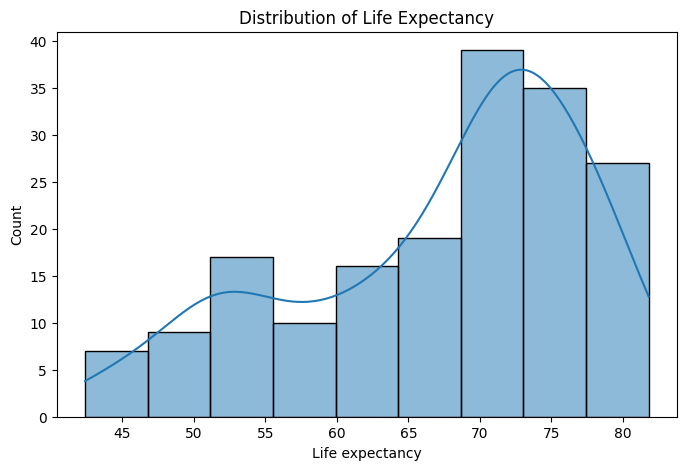

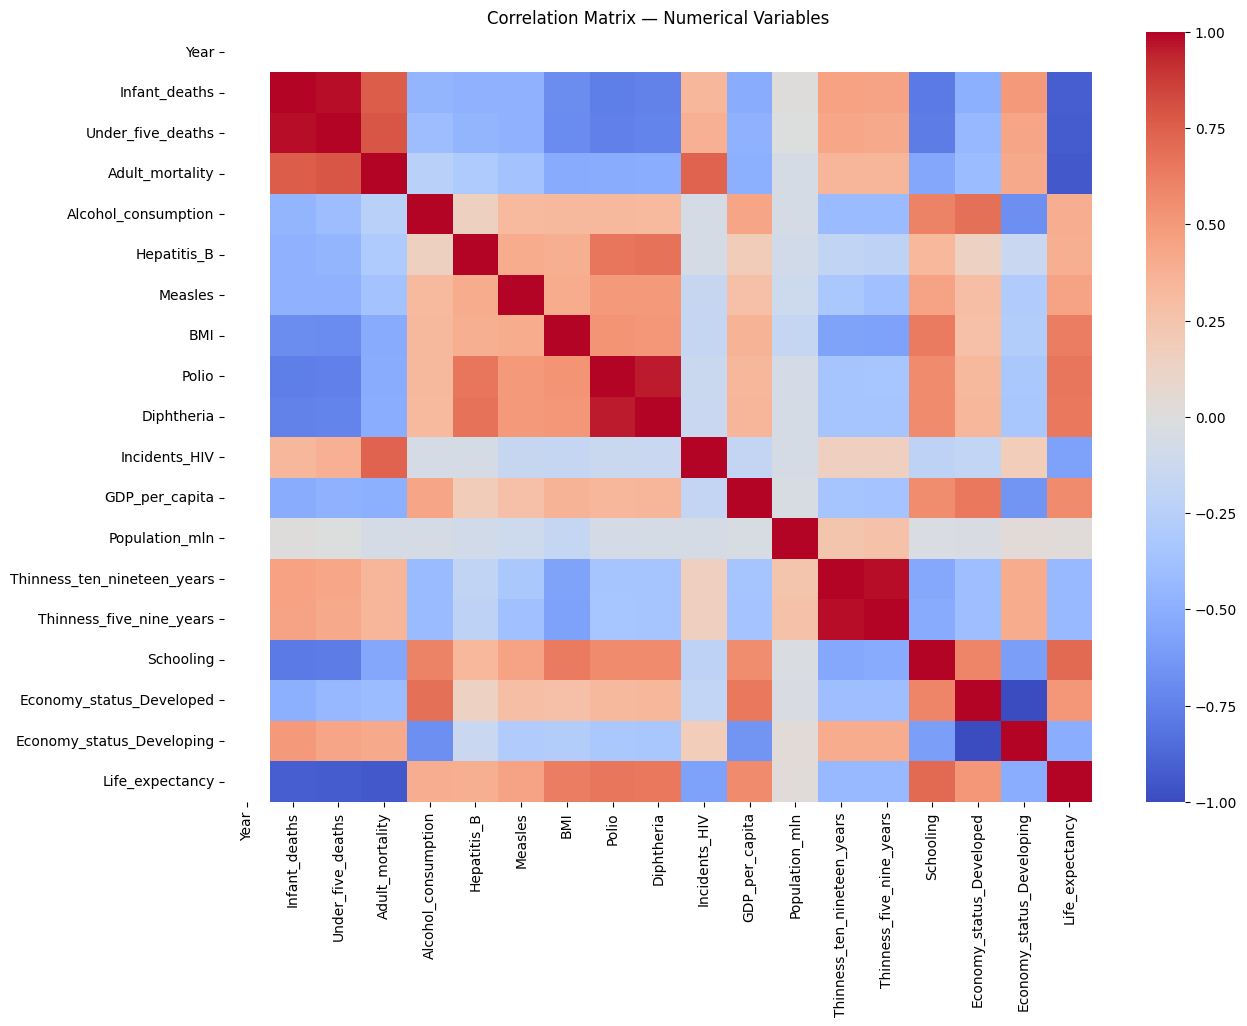

In [508]:
df = df[df['Year'] == 2003]

# Summary statistics
display(df.describe().T)

# Unique values in categorical variables
print("Countries:", df["Country"].nunique())
print("Regions:", df["Region"].nunique())

# Target distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["Life_expectancy"], kde=True)
plt.title("Distribution of Life Expectancy")
plt.xlabel("Life expectancy")
plt.show()

# Correlation heatmap for numerical variables
plt.figure(figsize=(14, 10))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Numerical Variables")
plt.show()


## 4. Define predictors and target

`Life_expectancy` is the response.

`Country` is excluded from the model because one-hot encoding almost 200 country indicators would turn the model into a country-fixed-effect model and can dominate the intended general relationship. `Region` is retained as the categorical geographic variable.

The two economy-status indicator columns are represented by a single binary variable to avoid perfect linear dependence with an intercept.


In [509]:
# Create a single economy-status indicator
# 1 = Developing, 0 = Developed
df["Economy_status"] = df["Economy_status_Developing"]

# Predictor columns
target = "Life_expectancy"

numeric_features = ["Infant_deaths",
    "Alcohol_consumption",
    "Hepatitis_B",
    "Measles",
    "BMI",
    "Polio",
    "Diphtheria",
    "Incidents_HIV",
    "GDP_per_capita",
    "Population_mln",
    "Thinness_ten_nineteen_years",
    "Thinness_five_nine_years",
    "Schooling",
    "Economy_status"
]



## 5. Train/Test Split

The test set is held out completely and is used only for the final comparison.

All scaling and one-hot encoding are fitted on the training data only.


In [510]:
categorical_features = ["Region"]

# Rebuild X to include Region
X = df[numeric_features + categorical_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])


numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("onehot", OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

Training observations: 143
Testing observations: 36


# 6. Multiple Linear Regression (OLS)

OLS is used as the baseline model. The same preprocessing is used for the regularized models so the comparison is fair.


In [511]:
ols_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

ols_pipeline.fit(X_train, y_train)

y_pred_ols = ols_pipeline.predict(X_test)

ols_r2 = r2_score(y_test, y_pred_ols)
ols_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ols))
ols_mae = mean_absolute_error(y_test, y_pred_ols)

print("OLS Test R²  :", round(ols_r2, 4))
print("OLS Test RMSE:", round(ols_rmse, 4))
print("OLS Test MAE :", round(ols_mae, 4))


OLS Test R²  : 0.9253
OLS Test RMSE: 2.6654
OLS Test MAE : 2.0682


# 7. Linear Regression Assumption Checks

The following assumptions/diagnostics are examined:

- **Linearity:** residuals versus fitted values.
- **Normality of residuals:** Q-Q plot and Shapiro-Wilk test on a sample when necessary.
- **Homoskedasticity:** residuals versus fitted values and Breusch-Pagan test.
- **Independence:** Durbin-Watson statistic.
- **Multicollinearity:** VIF.
- **Influential observations:** Cook's distance.

A statistical test should not be interpreted mechanically; plots and subject-matter context are considered together.


In [512]:
# Extract the transformed design matrix and residuals
X_train_transformed = ols_pipeline.named_steps["preprocessor"].transform(X_train)
y_train_pred_ols = ols_pipeline.predict(X_train)

residuals = y_train - y_train_pred_ols
fitted = y_train_pred_ols

print("Training residual mean:", residuals.mean())
print("Training residual SD:", residuals.std())


Training residual mean: -3.7266227400005255e-15
Training residual SD: 2.276196528656974


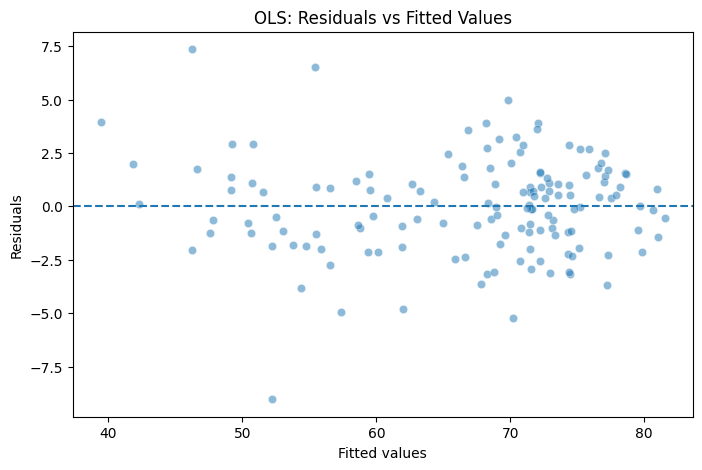

In [513]:
# ------------------------------------------------------------
# 7.1 Linearity: Residuals vs Fitted
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
sns.scatterplot(x=fitted, y=residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("OLS: Residuals vs Fitted Values")
plt.show()


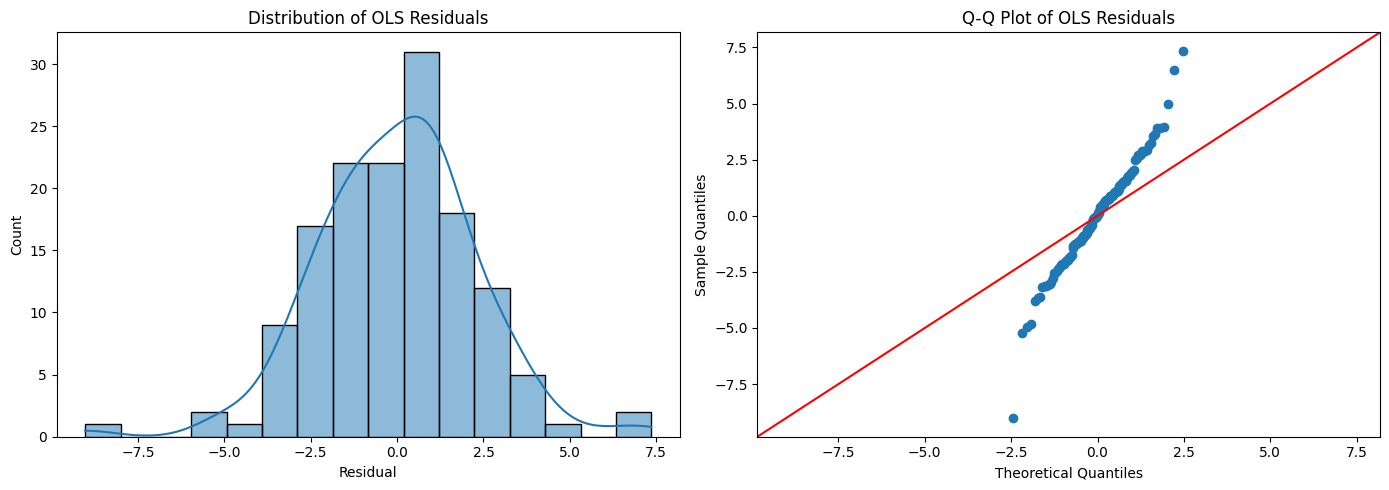

Shapiro-Wilk statistic: 0.9816
Shapiro-Wilk p-value : 0.0511261
Result: do not reject normality at the 5% level.


In [514]:
# ------------------------------------------------------------
# 7.2 Normality: Histogram + Q-Q plot
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuals, kde=True, ax=axes[0])
axes[0].set_title("Distribution of OLS Residuals")
axes[0].set_xlabel("Residual")

sm.qqplot(residuals, line="45", ax=axes[1])
axes[1].set_title("Q-Q Plot of OLS Residuals")

plt.tight_layout()
plt.show()

# Shapiro-Wilk can be overly sensitive with large samples.
# Use at most 5000 observations.
shapiro_sample = residuals.sample(
    min(5000, len(residuals)),
    random_state=42
)

shapiro_stat, shapiro_p = stats.shapiro(shapiro_sample)

print("Shapiro-Wilk statistic:", round(shapiro_stat, 4))
print("Shapiro-Wilk p-value :", f"{shapiro_p:.6g}")

if shapiro_p < 0.05:
    print("Result: reject normality at the 5% level.")
else:
    print("Result: do not reject normality at the 5% level.")


In [515]:
# ------------------------------------------------------------
# 7.3 Homoskedasticity: Breusch-Pagan test
# ------------------------------------------------------------

# Add constant for statsmodels diagnostic
X_bp = sm.add_constant(X_train_transformed)

bp_lm, bp_lm_pvalue, bp_fvalue, bp_f_pvalue = het_breuschpagan(
    residuals,
    X_bp
)

print("Breusch-Pagan LM statistic :", round(bp_lm, 4))
print("Breusch-Pagan LM p-value   :", f"{bp_lm_pvalue:.6g}")
print("Breusch-Pagan F statistic  :", round(bp_fvalue, 4))
print("Breusch-Pagan F p-value    :", f"{bp_f_pvalue:.6g}")

if bp_lm_pvalue < 0.05:
    print("Result: evidence of heteroskedasticity at the 5% level.")
else:
    print("Result: no significant evidence of heteroskedasticity at the 5% level.")


Breusch-Pagan LM statistic : 30.5221
Breusch-Pagan LM p-value   : 0.106318
Breusch-Pagan F statistic  : 1.4801
Breusch-Pagan F p-value    : 0.0935584
Result: no significant evidence of heteroskedasticity at the 5% level.


In [516]:
# ------------------------------------------------------------
# 7.4 Independence: Durbin-Watson
# ------------------------------------------------------------

dw = durbin_watson(residuals)

print("Durbin-Watson statistic:", round(dw, 4))

if 1.5 <= dw <= 2.5:
    print("Result: residual autocorrelation does not appear substantial.")
elif dw < 1.5:
    print("Result: possible positive autocorrelation.")
else:
    print("Result: possible negative autocorrelation.")

Durbin-Watson statistic: 1.6965
Result: residual autocorrelation does not appear substantial.


In [517]:
# ------------------------------------------------------------
# 7.5 Multicollinearity: VIF
# ------------------------------------------------------------

# VIF is evaluated on the transformed training design matrix.
# One-hot encoding has already removed one category per categorical variable.

feature_names = ols_pipeline.named_steps["preprocessor"].get_feature_names_out()

vif_df = pd.DataFrame({
    "Feature": feature_names,
    "VIF": [
        variance_inflation_factor(X_train_transformed, i)
        for i in range(X_train_transformed.shape[1])
    ]
}).sort_values("VIF", ascending=False)

display(vif_df)

print("\nCommon rule of thumb:")
print("VIF < 5   : usually acceptable")
print("VIF 5-10  : potentially problematic")
print("VIF > 10  : strong multicollinearity")


,Feature,VIF
11,num__Thinness_five_nine_years,26.480980
10,num__Thinness_ten_nineteen_years,24.184604
5,num__Polio,15.241526
6,num__Diphtheria,13.633503
13,num__Economy_status,5.884936
0,num__Infant_deaths,5.848586
12,num__Schooling,4.768023
4,num__BMI,4.040046
16,cat__Region_European Union,2.987901
1,num__Alcohol_consumption,2.934712



Common rule of thumb:
VIF < 5   : usually acceptable
VIF 5-10  : potentially problematic
VIF > 10  : strong multicollinearity


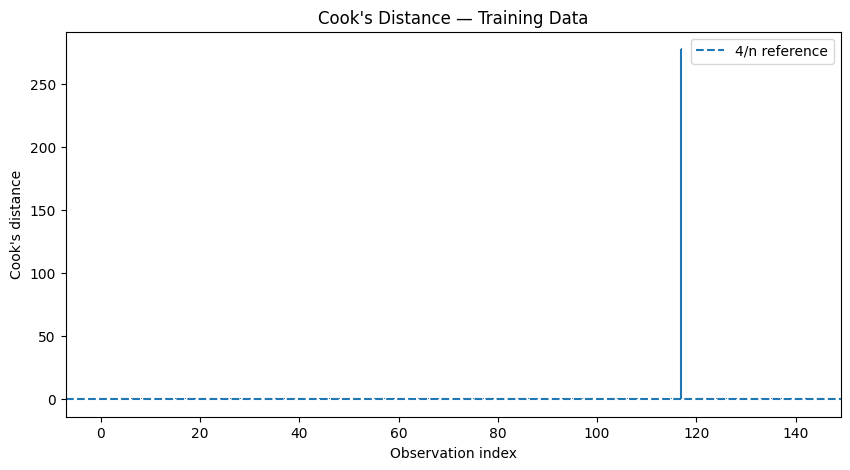

Maximum Cook's distance: 277.5096
Observations above 4/n: 10


In [518]:
# ------------------------------------------------------------
# 7.6 Influential observations: Cook's Distance
# ------------------------------------------------------------

# Fit an equivalent OLS model in statsmodels on the transformed
# training matrix solely for influence diagnostics.
X_sm = sm.add_constant(X_train_transformed)
ols_sm = sm.OLS(y_train, X_sm).fit()

influence = ols_sm.get_influence()
cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(10, 5))
plt.stem(
    np.arange(len(cooks_d)),
    cooks_d,
    markerfmt=",",
    basefmt=" "
)
plt.axhline(4 / len(cooks_d), linestyle="--",
            label="4/n reference")
plt.xlabel("Observation index")
plt.ylabel("Cook's distance")
plt.title("Cook's Distance — Training Data")
plt.legend()
plt.show()

print("Maximum Cook's distance:", round(cooks_d.max(), 4))
print("Observations above 4/n:",
      int(np.sum(cooks_d > 4 / len(cooks_d))))


# 8. Principal Component Regression (PCR)

PCA is added **after the train/test split** so that the principal components are learned from the training data only.

The steps are:

1. Fit the existing preprocessing pipeline on the training set.
2. Standardize the predictors.
3. Fit PCA on the **training data only**.
4. Retain enough principal components to explain **95% of the training variance**.
5. Fit Linear Regression using those principal components.
6. Transform the untouched test set using the already-fitted preprocessing and PCA.
7. Evaluate PCR on the same test set used by OLS, Ridge and Lasso.

This avoids data leakage and also shows whether dimensionality reduction can maintain predictive performance while reducing the number of dimensions.


In [519]:
# ============================================================
# 8.1 PCA + Linear Regression (Principal Component Regression)
# ============================================================

from sklearn.decomposition import PCA

# IMPORTANT:
# Fit preprocessing on training data only.
# The test set is transformed only after preprocessing/PCA are fitted.
pca_preprocessor = preprocessor.fit(X_train, y_train)

X_train_processed = pca_preprocessor.transform(X_train)
X_test_processed = pca_preprocessor.transform(X_test)

# PCA fitted ONLY on the training data.
# Keep enough PCs to explain 95% of the training variance.
pca = PCA(n_components=0.95, svd_solver="full", random_state=42)

X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)

print("Original transformed features:", X_train_processed.shape[1])
print("Number of principal components retained:", X_train_pca.shape[1])
print("Variance explained by retained PCs:",
      round(pca.explained_variance_ratio_.sum(), 4))

# Fit linear regression on the principal components
pcr_model = LinearRegression()
pcr_model.fit(X_train_pca, y_train)

# Test predictions
y_pred_pcr = pcr_model.predict(X_test_pca)

pcr_r2 = r2_score(y_test, y_pred_pcr)
pcr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_pcr))
pcr_mae = mean_absolute_error(y_test, y_pred_pcr)

print("\nPCR Test R²   :", round(pcr_r2, 4))
print("PCR Test RMSE :", round(pcr_rmse, 4))
print("PCR Test MAE  :", round(pcr_mae, 4))


Original transformed features: 22
Number of principal components retained: 11
Variance explained by retained PCs: 0.9602

PCR Test R²   : 0.8798
PCR Test RMSE : 3.3804
PCR Test MAE  : 2.8571


,PC,Explained_Variance,Cumulative_Variance
0,1,0.421487,0.421487
1,2,0.118150,0.539637
2,3,0.100500,0.640137
3,4,0.072890,0.713027
4,5,0.056368,0.769395
5,6,0.045980,0.815376
6,7,0.041225,0.856601
7,8,0.036913,0.893514
8,9,0.028533,0.922047
9,10,0.019272,0.941320


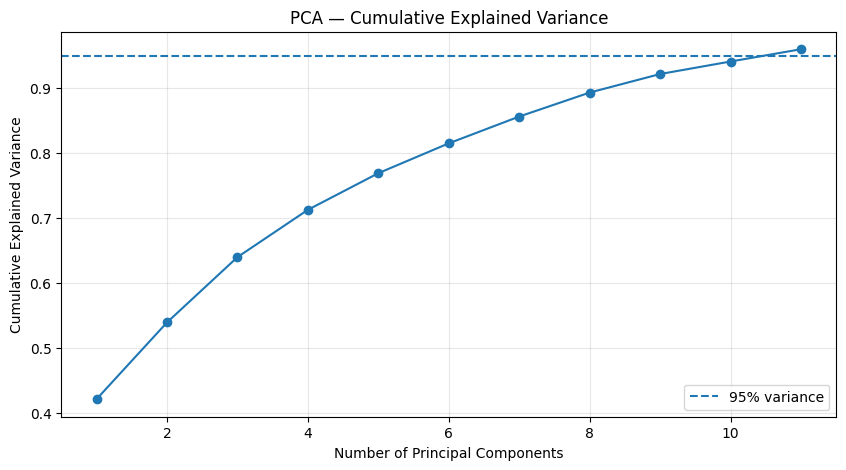

In [520]:
# ============================================================
# 8.2 PCA Explained Variance
# ============================================================

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

pca_variance_table = pd.DataFrame({
    "PC": np.arange(1, len(pca.explained_variance_ratio_) + 1),
    "Explained_Variance": pca.explained_variance_ratio_,
    "Cumulative_Variance": cumulative_variance
})

display(pca_variance_table)

plt.figure(figsize=(10, 5))
plt.plot(
    np.arange(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)
plt.axhline(0.95, linestyle="--", label="95% variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA — Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 9. Ridge Regression

Ridge regression is sensitive to the scale of predictors, which is why the preprocessing pipeline standardizes numerical variables.

The regularization parameter `alpha` is selected using **5-fold cross-validation on the training data only**. The test set remains untouched.


In [521]:
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

alpha_grid = {
    "model__alpha": np.logspace(-4, 4, 100)
}

cv = KFold(n_splits=3, shuffle=True, random_state=42)

ridge_search = GridSearchCV(
    ridge_pipeline,
    param_grid=alpha_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

ridge_search.fit(X_train, y_train)

best_ridge_alpha = ridge_search.best_params_["model__alpha"]
ridge_model = ridge_search.best_estimator_

y_pred_ridge = ridge_model.predict(X_test)

ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

print("Best Ridge alpha:", best_ridge_alpha)
print("Ridge Test R²   :", round(ridge_r2, 4))
print("Ridge Test RMSE :", round(ridge_rmse, 4))
print("Ridge Test MAE  :", round(ridge_mae, 4))


Best Ridge alpha: 3.351602650938848
Ridge Test R²   : 0.926
Ridge Test RMSE : 2.6533
Ridge Test MAE  : 2.1618


# 10. Lasso Regression

Lasso performs both regularization and variable selection by shrinking some coefficients exactly to zero.

Again, `alpha` is selected using 5-fold cross-validation on the training set.


In [522]:
lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(max_iter=100000))
])

lasso_search = GridSearchCV(
    lasso_pipeline,
    param_grid=alpha_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

lasso_search.fit(X_train, y_train)

best_lasso_alpha = lasso_search.best_params_["model__alpha"]
lasso_model = lasso_search.best_estimator_

y_pred_lasso = lasso_model.predict(X_test)

lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)

print("Best Lasso alpha:", best_lasso_alpha)
print("Lasso Test R²   :", round(lasso_r2, 4))
print("Lasso Test RMSE :", round(lasso_rmse, 4))
print("Lasso Test MAE  :", round(lasso_mae, 4))


Best Lasso alpha: 0.521400828799969
Lasso Test R²   : 0.9212
Lasso Test RMSE : 2.7377
Lasso Test MAE  : 2.1813


In [523]:
# ------------------------------------------------------------
# 9.1 Number of coefficients selected by Lasso
# ------------------------------------------------------------

lasso_preprocessor = lasso_model.named_steps["preprocessor"]
lasso_estimator = lasso_model.named_steps["model"]

lasso_feature_names = lasso_preprocessor.get_feature_names_out()
lasso_coefs = pd.Series(
    lasso_estimator.coef_,
    index=lasso_feature_names
)

nonzero = (lasso_coefs != 0).sum()
zero = (lasso_coefs == 0).sum()

print("Total coefficients:", len(lasso_coefs))
print("Non-zero coefficients:", nonzero)
print("Zero coefficients:", zero)


Total coefficients: 22
Non-zero coefficients: 3
Zero coefficients: 19


# 11. Compare OLS, Ridge, Lasso and PCR

All three models are evaluated on the **same untouched test set**.

- Higher R² is better.
- Lower RMSE is better.
- Lower MAE is better.

The CV-selected `alpha` values are reported for Ridge and Lasso.


In [524]:
# ============================================================
# 11. Final Model Comparison
# ============================================================

comparison = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso", "PCR"],
    "Test R²": [ols_r2, ridge_r2, lasso_r2, pcr_r2],
    "Test RMSE": [ols_rmse, ridge_rmse, lasso_rmse, pcr_rmse],
    "Test MAE": [ols_mae, ridge_mae, lasso_mae, pcr_mae],
    "Tuned alpha": ["—", best_ridge_alpha, best_lasso_alpha, "—"],
    "PCA components": ["—", "—", "—", pca.n_components_],
    "PCA variance retained": ["—", "—", "—", pca.explained_variance_ratio_.sum()]
})

# Lower RMSE/MAE and higher R² are better.
comparison = comparison.sort_values("Test RMSE").reset_index(drop=True)

display(comparison.style.format({
    "Test R²": "{:.4f}",
    "Test RMSE": "{:.4f}",
    "Test MAE": "{:.4f}",
    "PCA variance retained": lambda x: "—" if x == "—" else f"{x:.2%}"
}))

best_model = comparison.iloc[0]["Model"]
print(f"\nBest model by test RMSE: {best_model}")


,Model,Test R²,Test RMSE,Test MAE,Tuned alpha,PCA components,PCA variance retained
0,Ridge,0.9260,2.6533,2.1618,3.351603,—,—
1,OLS,0.9253,2.6654,2.0682,—,—,—
2,Lasso,0.9212,2.7377,2.1813,0.521401,—,—
3,PCR,0.8798,3.3804,2.8571,—,11,96.02%



Best model by test RMSE: Ridge


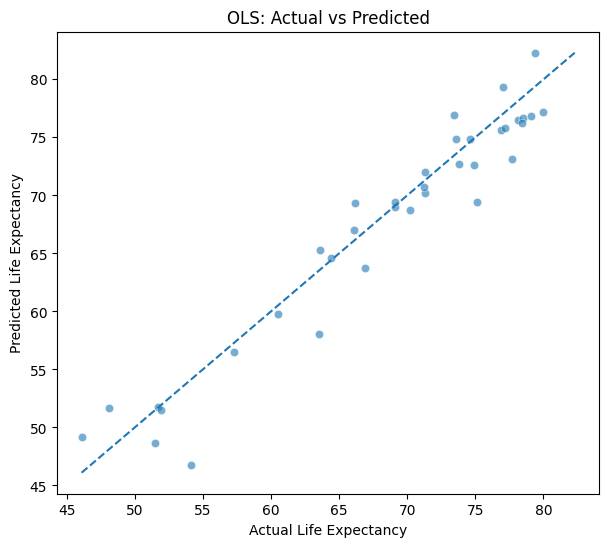

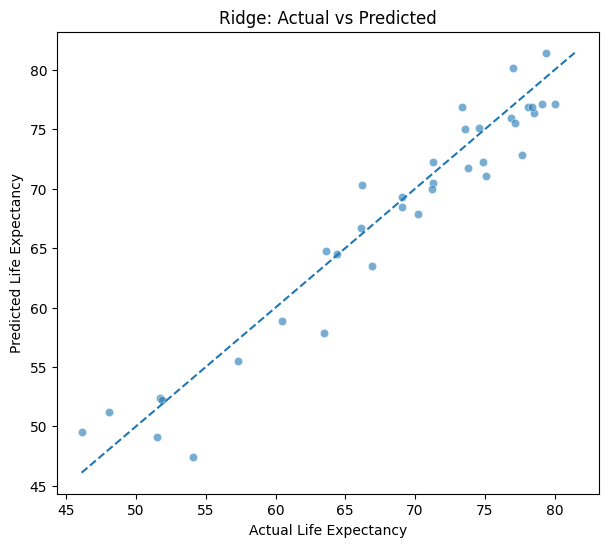

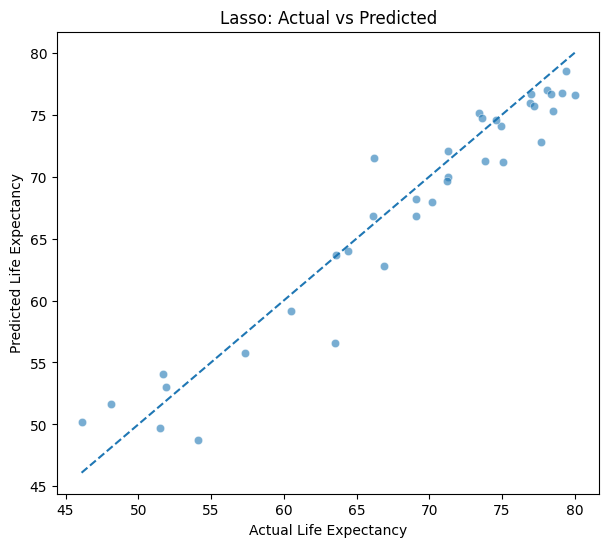

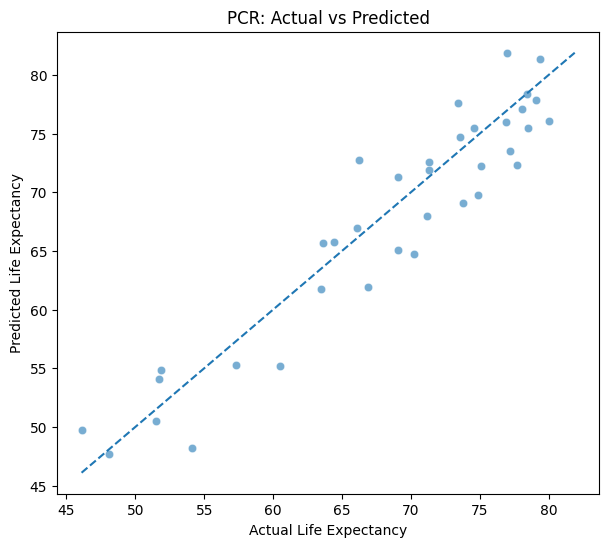

In [525]:
# ------------------------------------------------------------
# 10.1 Actual vs Predicted
# ------------------------------------------------------------

predictions = {
    "OLS": y_pred_ols,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso,
    "PCR": y_pred_pcr
}

for name, pred in predictions.items():
    plt.figure(figsize=(7, 6))
    sns.scatterplot(x=y_test, y=pred, alpha=0.6)

    min_val = min(y_test.min(), pred.min())
    max_val = max(y_test.max(), pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.xlabel("Actual Life Expectancy")
    plt.ylabel("Predicted Life Expectancy")
    plt.title(f"{name}: Actual vs Predicted")
    plt.show()


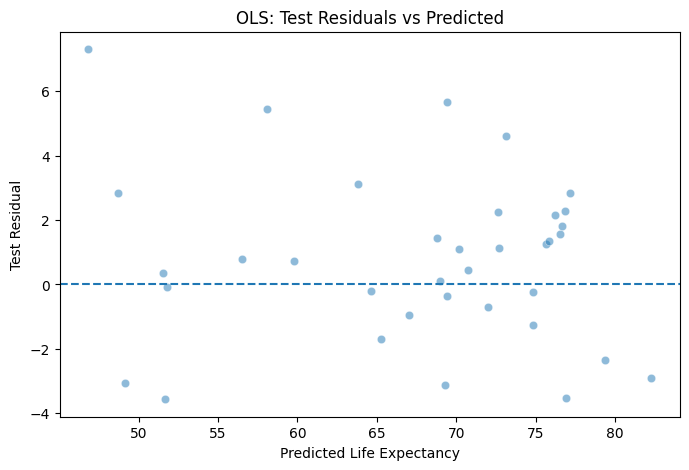

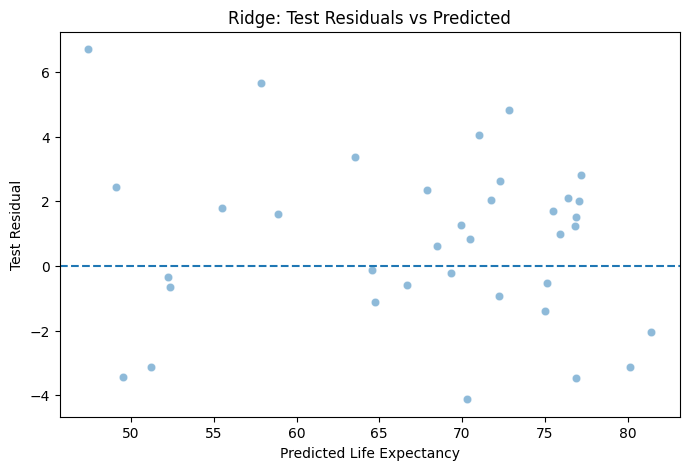

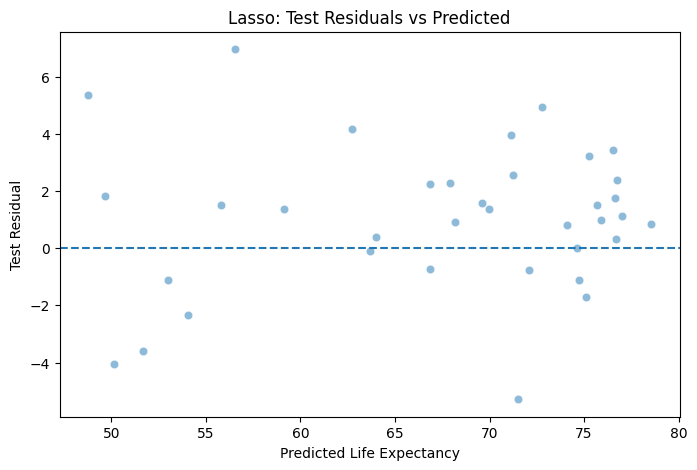

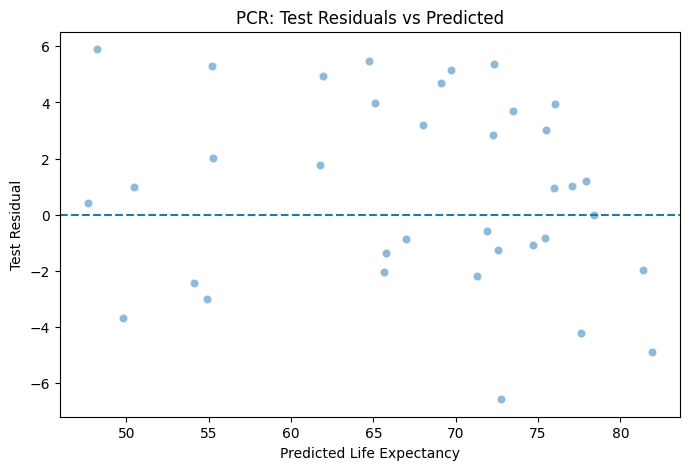

In [526]:
# ------------------------------------------------------------
# 10.2 Residual comparison
# ------------------------------------------------------------

for name, pred in predictions.items():
    residual = y_test - pred

    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=pred, y=residual, alpha=0.5)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted Life Expectancy")
    plt.ylabel("Test Residual")
    plt.title(f"{name}: Test Residuals vs Predicted")
    plt.show()


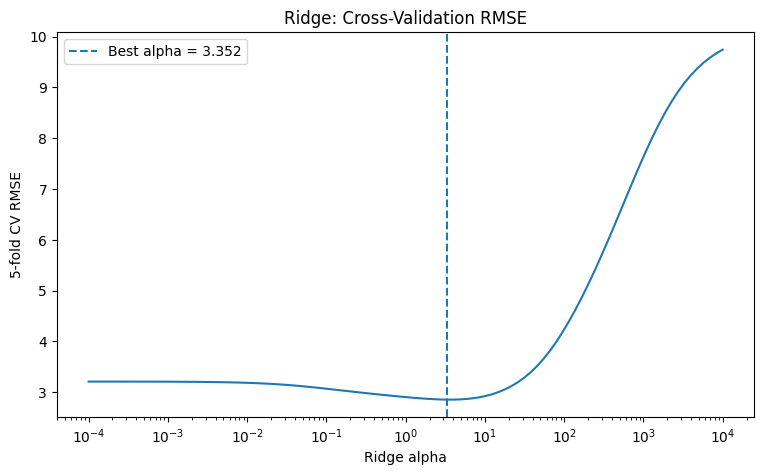

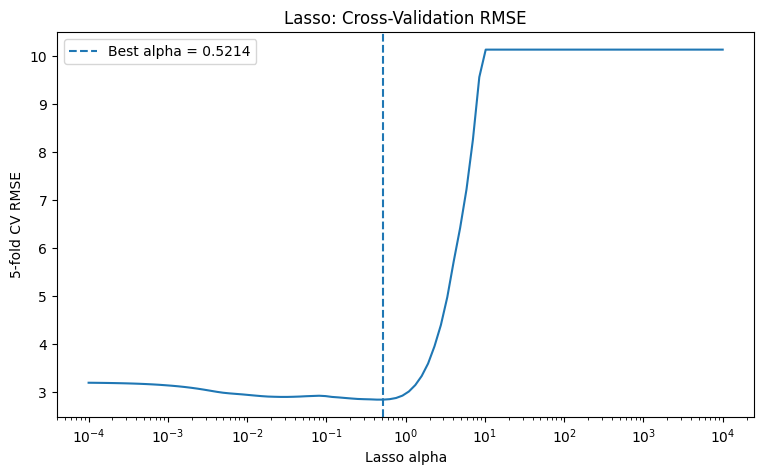

In [527]:
# ------------------------------------------------------------
# 10.3 CV curves for Ridge and Lasso
# ------------------------------------------------------------

ridge_results = pd.DataFrame(ridge_search.cv_results_)
lasso_results = pd.DataFrame(lasso_search.cv_results_)

plt.figure(figsize=(9, 5))
plt.semilogx(
    ridge_results["param_model__alpha"].astype(float),
    -ridge_results["mean_test_score"]
)
plt.axvline(best_ridge_alpha, linestyle="--",
            label=f"Best alpha = {best_ridge_alpha:.4g}")
plt.xlabel("Ridge alpha")
plt.ylabel("5-fold CV RMSE")
plt.title("Ridge: Cross-Validation RMSE")
plt.legend()
plt.show()

plt.figure(figsize=(9, 5))
plt.semilogx(
    lasso_results["param_model__alpha"].astype(float),
    -lasso_results["mean_test_score"]
)
plt.axvline(best_lasso_alpha, linestyle="--",
            label=f"Best alpha = {best_lasso_alpha:.4g}")
plt.xlabel("Lasso alpha")
plt.ylabel("5-fold CV RMSE")
plt.title("Lasso: Cross-Validation RMSE")
plt.legend()
plt.show()


In [528]:
# ------------------------------------------------------------
# Compare OLS, Ridge, and Lasso coefficients side by side
# ------------------------------------------------------------

ols_estimator = ols_pipeline.named_steps["model"]
ridge_estimator = ridge_model.named_steps["model"]
lasso_estimator = lasso_model.named_steps["model"]

feature_names = ols_pipeline.named_steps["preprocessor"].get_feature_names_out()

coef_comparison = pd.DataFrame({
    "Feature": feature_names,
    "OLS": ols_estimator.coef_,
    "Ridge": ridge_estimator.coef_,
    "Lasso": lasso_estimator.coef_
})

# Focus on the known collinear pair to see the effect directly
collinear_features = ["num__Thinness_ten_nineteen_years", "num__Thinness_five_nine_years",
                       "num__Polio", "num__Diphtheria"]

print("Full comparison:")
display(coef_comparison.sort_values("OLS", key=abs, ascending=False))

print("\nFocus on collinear pairs:")
display(coef_comparison[coef_comparison["Feature"].isin(collinear_features)])

Full comparison:


,Feature,OLS,Ridge,Lasso
0,num__Infant_deaths,-6.928291,-6.333112,-7.349762
21,cat__Region_South America,2.938083,1.816592,0.000000
7,num__Incidents_HIV,-2.904378,-3.028925,-2.813251
15,cat__Region_Central America and Caribbean,2.655095,1.827563,0.000000
16,cat__Region_European Union,-2.381392,-1.286037,0.000000
14,cat__Region_Asia,2.216362,1.381051,0.000000
13,num__Economy_status,-2.195517,-1.513933,-0.000000
18,cat__Region_North America,-1.139192,-0.055188,0.000000
19,cat__Region_Oceania,-1.079718,-0.712090,-0.000000
17,cat__Region_Middle East,0.879094,0.632405,0.000000



Focus on collinear pairs:


,Feature,OLS,Ridge,Lasso
5,num__Polio,0.086269,0.411236,0.0
6,num__Diphtheria,0.152875,0.180733,0.0
10,num__Thinness_ten_nineteen_years,-0.197543,-0.163137,-0.0
11,num__Thinness_five_nine_years,0.126044,0.119555,-0.0
